<a href="https://colab.research.google.com/github/gauravbhatia-bit/Churn-Analysis/blob/main/MachinelearningWeek2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, classification_report

In [5]:
df=pd.read_csv("/content/bank_data_with_NaN.csv")

df.head(25)


,id,last_name,credit_score,country,gender,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained
0,15634602.0,Hargrave,619.0,Switzerland,f,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,0.0
1,15647311.0,Hill,608.0,Austria,f,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,1.0
2,15619304.0,Onio,502.0,Switzerland,f,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,0.0
3,15701354.0,Boni,699.0,Switzerland,f,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,1.0
4,15737888.0,Mitchell,850.0,Austria,f,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,1.0
5,15574012.0,Chu,645.0,Austria,m,44.0,8.0,113755.78,2.0,1.0,0.0,149756.71,0.0
6,15592531.0,Bartlett,822.0,Switzerland,m,50.0,7.0,0.00,2.0,1.0,1.0,10062.80,NaN
7,15656148.0,Obinna,376.0,Germany,f,29.0,4.0,115046.74,4.0,1.0,0.0,119346.88,0.0
8,15792365.0,He,501.0,Switzerland,m,44.0,4.0,142051.07,2.0,0.0,1.0,74940.50,1.0
9,15592389.0,Hu,684.0,Switzerland,m,27.0,2.0,134603.88,1.0,1.0,1.0,71725.73,1.0


Data Exploration/ Cleaning/ Quality Check

In [6]:
df.isna().sum()

,0
id,102
last_name,76
credit_score,69
country,80
gender,73
age,79
years_customer,85
balance_euros,77
num_products,64
has_credit_card,73


In [7]:
med= df['age'].median()
print(med)
df['age']= df['age'].fillna(med)


med= df['credit_score'].median()
df['credit_score']= df['credit_score'].fillna(med)


med= df['balance_euros'].median()
df['balance_euros']= df['balance_euros'].fillna(med)



med= df['salary_euros'].median()
df['salary_euros']= df['salary_euros'].fillna(med)

med = df['years_customer'].median()
df['years_customer'] = df['years_customer'].fillna(med)

# By probs

probs= df['country'].value_counts(normalize=True)
n_missing= df['country'].isna().sum()
fill_values= np.random.choice(probs.index, p = probs.values, size= n_missing)
df.loc[df['country'].isna(), 'country']= fill_values

probs= df['gender'].value_counts(normalize=True)
n_missing= df['gender'].isna().sum()
fill_values= np.random.choice(probs.index, p = probs.values, size= n_missing)
df.loc[df['gender'].isna(), 'gender']= fill_values


probs= df['num_products'].value_counts(normalize=True)
n_missing= df['num_products'].isna().sum()
fill_values= np.random.choice(probs.index, p = probs.values, size= n_missing)
df.loc[df['num_products'].isna(), 'num_products']= fill_values


probs= df['has_credit_card'].value_counts(normalize=True)
n_missing= df['has_credit_card'].isna().sum()
fill_values= np.random.choice(probs.index, p = probs.values, size= n_missing)
df.loc[df['has_credit_card'].isna(), 'has_credit_card']= fill_values


probs= df['is_active'].value_counts(normalize=True)
n_missing= df['is_active'].isna().sum()
fill_values= np.random.choice(probs.index, p = probs.values, size= n_missing)
df.loc[df['is_active'].isna(), 'is_active']= fill_values


probs= df['retained'].value_counts(normalize=True)
n_missing= df['retained'].isna().sum()
fill_values= np.random.choice(probs.index, p = probs.values, size= n_missing)
df.loc[df['retained'].isna(), 'retained']= fill_values

#drop collumns of no usage
if 'last_name' in df.columns:
 df= df.drop('last_name', axis=1)

if 'id' in df.columns:
 df= df.drop('id', axis=1)


df.isna().sum()





37.0


,0
credit_score,0
country,0
gender,0
age,0
years_customer,0
balance_euros,0
num_products,0
has_credit_card,0
is_active,0
salary_euros,0


Categorical feature distribution

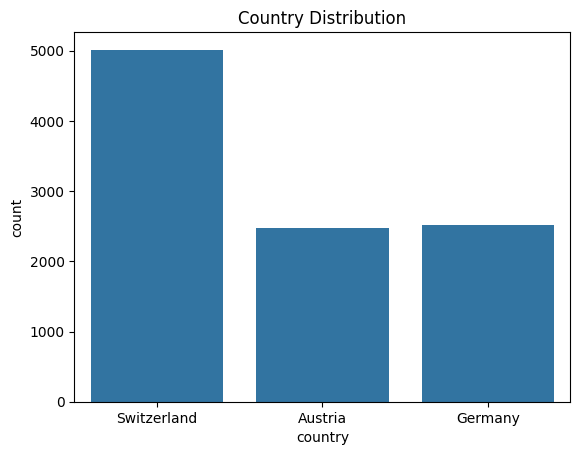

In [8]:
sns.countplot(data=df, x='country')
plt.title('Country Distribution')
plt.xlabel('country')
plt.ylabel('count')
plt.show()

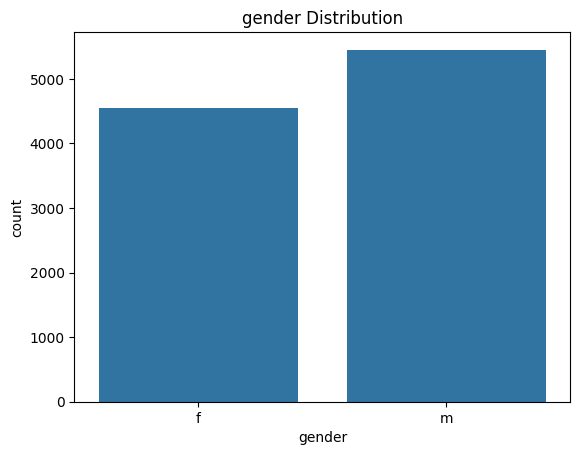

In [9]:
sns.countplot(data=df, x='gender')
plt.title('gender Distribution')
plt.xlabel('gender')
plt.ylabel('count')
plt.show()

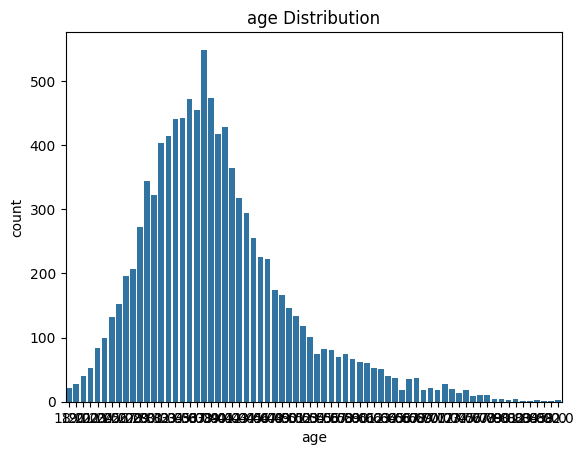

In [10]:
sns.countplot(data=df, x='age')
plt.title('age Distribution')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

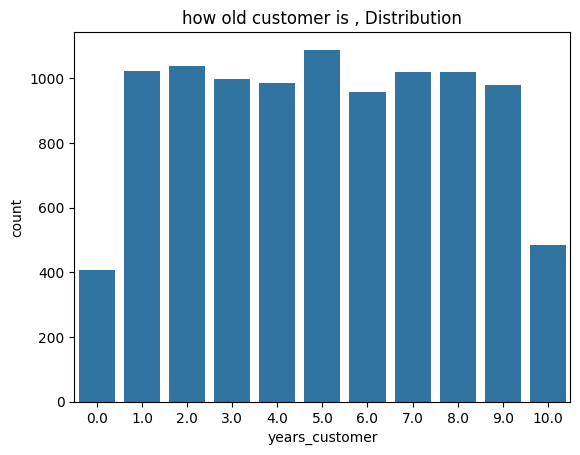

In [11]:
sns.countplot(data=df, x='years_customer')
plt.title('how old customer is , Distribution')
plt.xlabel('years_customer')
plt.ylabel('count')
plt.show()

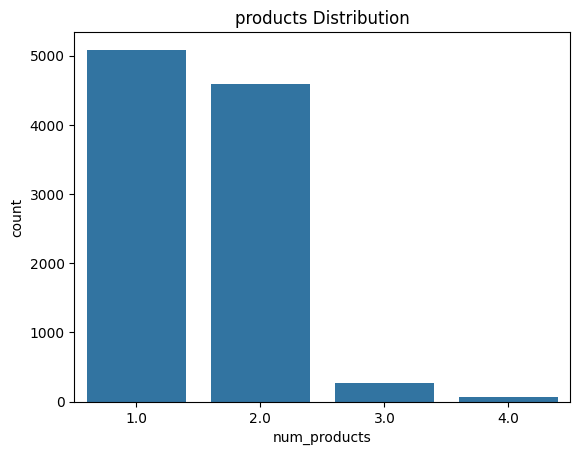

In [12]:
sns.countplot(data=df, x='num_products')
plt.title('products Distribution')
plt.xlabel('num_products')
plt.ylabel('count')
plt.show()

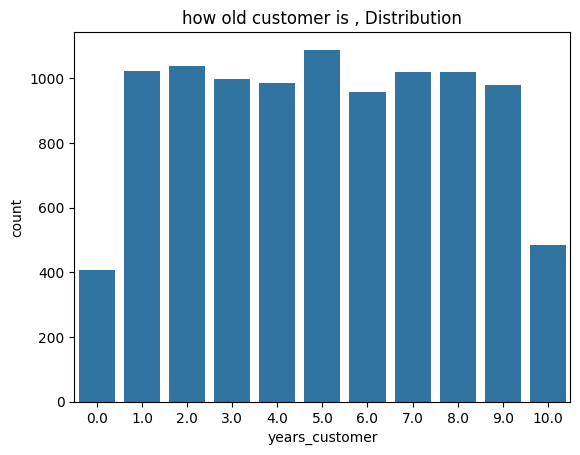

In [13]:
sns.countplot(data=df, x='years_customer')
plt.title('how old customer is , Distribution')
plt.xlabel('years_customer')
plt.ylabel('count')
plt.show()

In [14]:
# Pie Charts

gender_counts = df['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'count']
fig = px.pie(gender_counts, values='count', names='gender', title='Gender Distribution')
fig.show()

In [15]:
value_counts = df['num_products'].value_counts().reset_index()
value_counts.columns = ['num_products','count']
fig = px.pie(value_counts, values='count', names='num_products', title='product wise distribution')
fig.show()
print(value_counts)

   num_products  count
0           1.0   5087
1           2.0   4587
2           3.0    265
3           4.0     61


In [16]:
fig = px.pie(df, names='has_credit_card', title='credit card distribution')
fig.show()

In [17]:
fig = px.pie(df,names = 'is_active', title = 'distribution based on acitvity')
fig.show()

In [18]:
retained_counts = df["retained"].value_counts().reset_index()
retained_counts.columns = ["retained(1)","counts(0)"]
print(retained_counts.columns)

fig = px.pie(df, names = 'retained', title = 'churned or not')
fig.show()

Index(['retained(1)', 'counts(0)'], dtype='object')


**Compare retained with other features**

<Axes: >

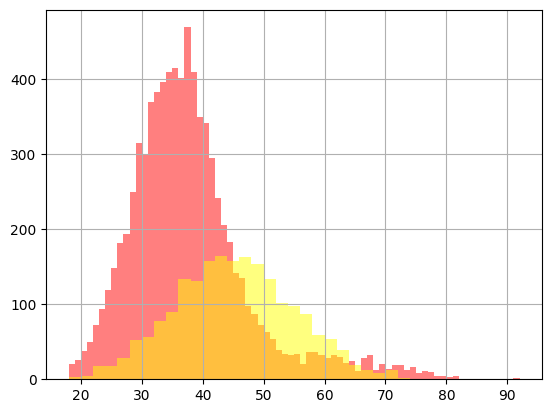

In [19]:
df[df['retained']==1]['age'].hist(bins='auto', color=
                                  'red', alpha=0.5)
df[df['retained']==0]['age'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

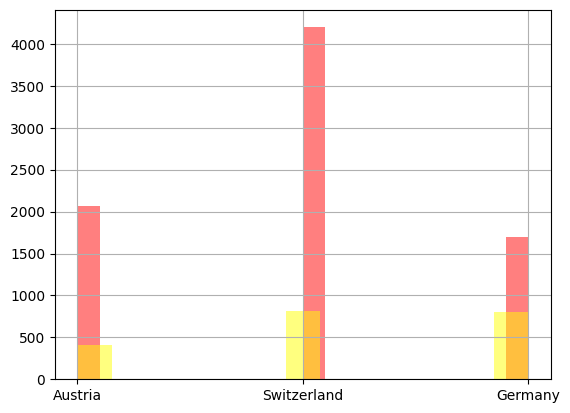

In [20]:

df[df['retained']==1]['country'].hist(bins='auto', color=
                                  'red', alpha=0.5)
df[df['retained']==0]['country'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

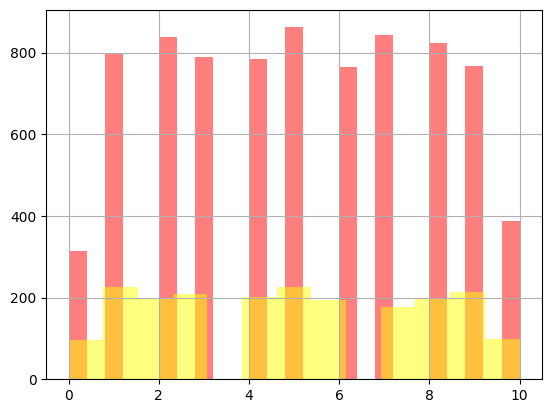

In [21]:
df[df['retained']==1]['years_customer'].hist(bins='auto', color=
                                  'red', alpha=0.5)
df[df['retained']==0]['years_customer'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

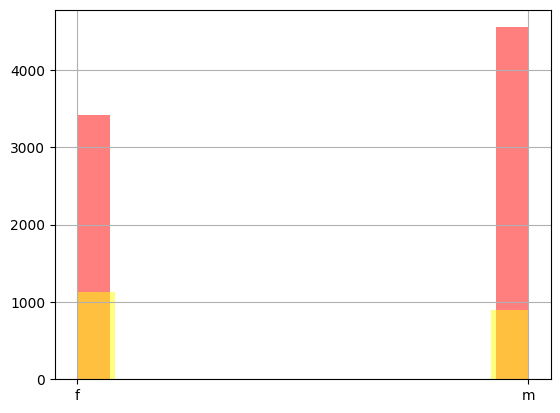

In [22]:
df[df['retained']==1]['gender'].hist(bins='auto', color=
                                  'red', alpha=0.5)
df[df['retained']==0]['gender'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

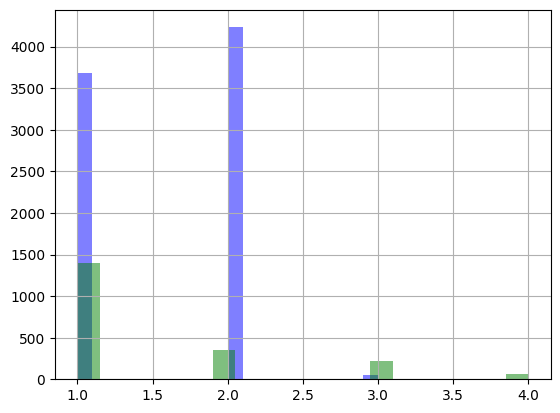

In [23]:
df[df['retained']==1]['num_products'].hist(bins='auto', color=
                                  'blue', alpha=0.5)
df[df['retained']==0]['num_products'].hist(bins='auto', color=
                                  'green', alpha=0.5)

<Axes: >

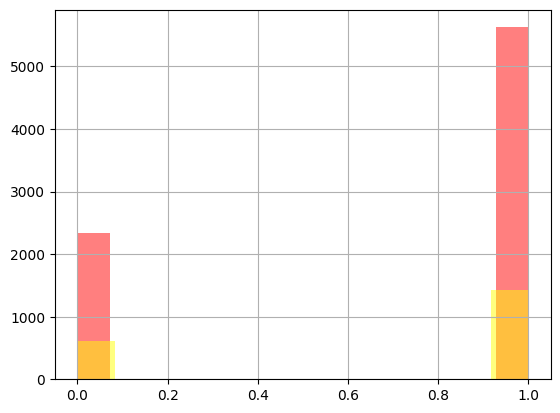

In [24]:
df[df['retained']==1]['has_credit_card'].hist(bins='auto', color=
                                  'red', alpha=0.5)
df[df['retained']==0]['has_credit_card'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

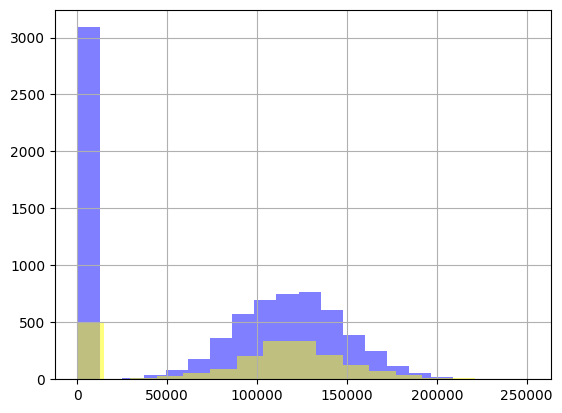

In [25]:
df[df['retained']==1]['balance_euros'].hist(bins='auto', color=
                                  'blue', alpha=0.5)
df[df['retained']==0]['balance_euros'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

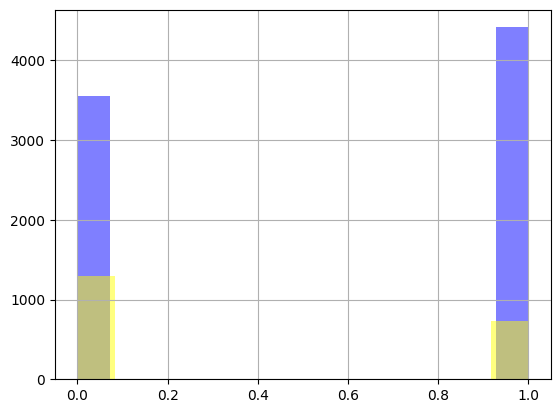

In [26]:
df[df['retained']==1]['is_active'].hist(bins='auto', color=
                                  'blue', alpha=0.5)
df[df['retained']==0]['is_active'].hist(bins='auto', color=
                                  'yellow', alpha=0.5)

<Axes: >

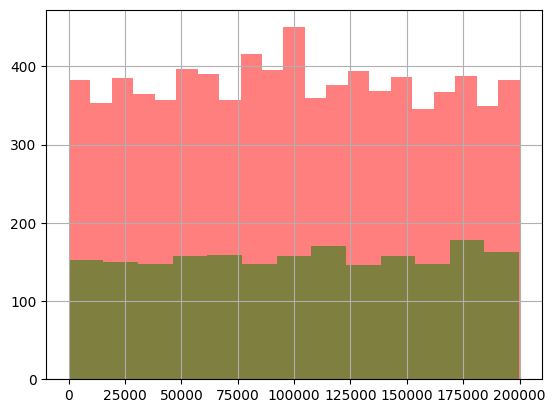

In [27]:
df[df['retained']==1]['salary_euros'].hist(bins='auto', color=
                                  'red', alpha=0.5)
df[df['retained']==0]['salary_euros'].hist(bins='auto', color=
                                  'green', alpha=0.5)

**Correlation Check**

In [28]:
df.corr(numeric_only=True)

,credit_score,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained
credit_score,1.000000,-0.003786,0.000959,0.006872,0.012392,-0.007381,0.026020,-0.001331,0.027741
age,-0.003786,1.000000,-0.008668,0.029231,-0.030163,-0.010418,0.083623,-0.007079,-0.283008
years_customer,0.000959,-0.008668,1.000000,-0.010926,0.012833,0.022005,-0.027066,0.009479,0.013529
balance_euros,0.006872,0.029231,-0.010926,1.000000,-0.300274,-0.016125,-0.009570,0.014210,-0.115732
num_products,0.012392,-0.030163,0.012833,-0.300274,1.000000,0.003446,0.009657,0.016429,0.047174
has_credit_card,-0.007381,-0.010418,0.022005,-0.016125,0.003446,1.000000,-0.010113,-0.009689,0.007215
is_active,0.026020,0.083623,-0.027066,-0.009570,0.009657,-0.010113,1.000000,-0.009704,0.155307
salary_euros,-0.001331,-0.007079,0.009479,0.014210,0.016429,-0.009689,-0.009704,1.000000,-0.010958
retained,0.027741,-0.283008,0.013529,-0.115732,0.047174,0.007215,0.155307,-0.010958,1.000000


# Check for Imbalances

In [29]:
df['retained'].value_counts()

,count
retained,
1.0,7967
0.0,2033


In [30]:
df.head()

,credit_score,country,gender,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained
0,619.0,Switzerland,f,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,0.0
1,608.0,Austria,f,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,1.0
2,502.0,Switzerland,f,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,0.0
3,699.0,Switzerland,f,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,1.0
4,850.0,Austria,f,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,1.0


We can use oversampling or undersampling, but results are better in oversampling so we are going to use oversampling.

SMOTE or ADASYN are two methods for oversampling, so we are using SMOTE

But before oversampling we need to change our categorical features into numbers by Encoding.

In [31]:
pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)


,credit_score,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained,country_Germany,country_Switzerland,gender_m
0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,0.0,False,True,False
1,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,1.0,False,False,False
2,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,0.0,False,True,False
3,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,1.0,False,True,False
4,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,1.0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771.0,39.0,5.0,0.00,2.0,1.0,0.0,96270.64,1.0,False,True,True
9996,516.0,35.0,10.0,57369.61,1.0,1.0,1.0,101699.77,1.0,False,True,True
9997,709.0,36.0,7.0,0.00,1.0,0.0,1.0,42085.58,0.0,False,True,False
9998,772.0,42.0,3.0,75075.31,2.0,1.0,0.0,92888.52,0.0,True,False,True


###I want a matrix of only feature and table of only labels
### I want to devide the dataframe into big x and small y

In [32]:
y_org = df['retained'].to_numpy().astype(float)

In [33]:
df.drop('retained',axis = 1, inplace = True)

In [34]:
features_list = df.columns
features_list

Index(['credit_score', 'country', 'gender', 'age', 'years_customer',
       'balance_euros', 'num_products', 'has_credit_card', 'is_active',
       'salary_euros'],
      dtype='object')

In [35]:
X = df.values



In [36]:
df.head()

,credit_score,country,gender,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros
0,619.0,Switzerland,f,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,608.0,Austria,f,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,502.0,Switzerland,f,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,699.0,Switzerland,f,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,850.0,Austria,f,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10


In [37]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

In [38]:
X = df.values

In [39]:
X_org = X.astype(float)

In [40]:
y_org


array([0., 1., 0., ..., 0., 0., 1.])

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_org, y_org, test_size=0.33, random_state=42)

In [42]:
print(X_train.shape)
print(X_test.shape)

(6700, 11)
(3300, 11)


In [57]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train,y_train)
df_res = pd.DataFrame(X_res, columns=df.columns)

In [58]:
df_res['retained'] = y_res


In [59]:
df_res['retained'].value_counts()

,count
retained,
0.0,5310
1.0,5310


Our data has been balanced now

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
df_res

,credit_score,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,country_Germany,country_Switzerland,gender_m,retained
0,1.678504,-0.943877,0.007574,0.478219,-0.904317,-1.542310,-1.035557,1.508469,1.745949,-1.002391,-1.099561,0.0
1,0.303038,-0.179616,1.050289,-0.049056,0.819417,0.648378,0.965664,-1.316462,1.745949,-1.002391,0.909454,1.0
2,-0.103350,0.966776,-0.339998,0.334101,-0.904317,0.648378,-1.035557,-1.325531,1.745949,-1.002391,0.909454,0.0
3,-0.415956,-0.752812,1.050289,0.669538,-0.904317,0.648378,0.965664,-0.815716,-0.572754,0.997615,-1.099561,1.0
4,-0.686881,-0.561746,1.397860,-1.222584,-0.904317,0.648378,-1.035557,-1.634536,-0.572754,0.997615,0.909454,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10615,1.239175,1.072279,-0.680974,0.471212,-0.904317,0.648378,0.965664,-1.468724,-0.572754,0.997615,0.909454,0.0
10616,-0.545391,0.181646,-1.382712,0.395262,-0.904317,0.648378,-1.035557,-1.087651,1.745949,-1.002391,0.909454,0.0
10617,0.086596,-1.247307,-0.718189,-1.222584,-0.118376,0.648378,-1.035557,-1.333038,-0.572754,-1.002391,-1.099561,0.0
10618,-1.202352,1.516782,1.002075,0.650511,2.543151,0.648378,-1.035557,0.394982,-0.572754,0.997615,-1.099561,0.0


In [63]:
pd.DataFrame(X_train).describe().round(2)

,0,1,2,3,4,5,6,7,8,9,10
count,6700.00,6700.00,6700.00,6700.00,6700.00,6700.00,6700.00,6700.00,6700.00,6700.0,6700.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.0,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00
min,-3.15,-1.99,-1.73,-1.22,-0.90,-1.54,-1.04,-1.75,-0.57,-1.0,-1.10
25%,-0.69,-0.66,-1.04,-1.22,-0.90,-1.54,-1.04,-0.85,-0.57,-1.0,-1.10
50%,0.00,-0.18,0.01,0.33,-0.90,0.65,0.97,-0.01,-0.57,1.0,0.91
75%,0.70,0.49,0.70,0.82,0.82,0.65,0.97,0.86,-0.57,1.0,0.91
max,2.06,5.07,1.75,2.80,4.27,0.65,0.97,1.72,1.75,1.0,0.91


In [50]:
df.head()

,credit_score,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,country_Germany,country_Switzerland,gender_m
0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,False,True,False
1,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,False,False,False
2,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,False,True,False
3,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,False,True,False
4,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,False,False,False


In [64]:
# flip retained to churn (0→1, 1→0)
y_org = (y_org == 0).astype(float)  # retained=0 becomes churn=1, retained=1 becomes churn=0

# We will apply ML models now
# Linear Regression

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
# Run this cell FIRST
APPLY_SMOTE     = True
APPLY_SCALER    = True
SHOW_CONFMATRIX = True

In [66]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

              precision    recall  f1-score   support

         0.0       0.37      0.71      0.49       643
         1.0       0.91      0.71      0.80      2657

    accuracy                           0.71      3300
   macro avg       0.64      0.71      0.64      3300
weighted avg       0.81      0.71      0.74      3300



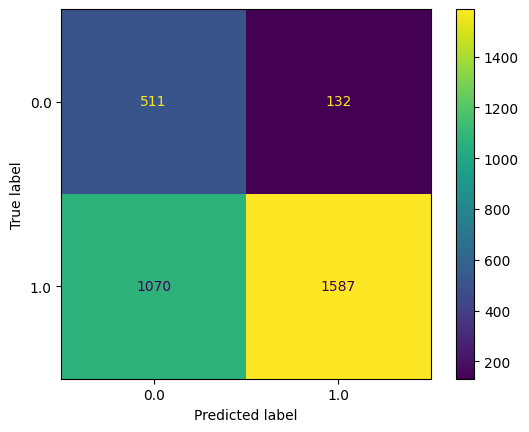

In [67]:
lr_clf = LogisticRegression()
lr_clf.fit(X_res_scaled, y_res)
y_pred = lr_clf.predict(X_test_scaled)
#prediction
if APPLY_SCALER:
    X_test_scaled = scaler.transform(X_test)
else:
    X_test_scaled = X_test


print(classification_report(y_test, y_pred))

if SHOW_CONFMATRIX:
    ConfusionMatrixDisplay.from_estimator(lr_clf, X_test, y_test)

              precision    recall  f1-score   support

         0.0       0.39      0.64      0.48       643
         1.0       0.90      0.75      0.82      2657

    accuracy                           0.73      3300
   macro avg       0.64      0.70      0.65      3300
weighted avg       0.80      0.73      0.75      3300



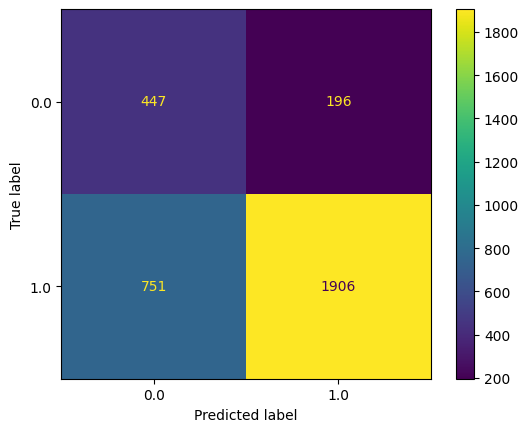

In [68]:
# KNN

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_res_scaled, y_res)

y_pred = knn_clf.predict(X_test_scaled)

if APPLY_SCALER:
    X_test_scaled = scaler.transform(X_test)
else:
    X_test_scaled = X_test


print(classification_report(y_test, y_pred))

if SHOW_CONFMATRIX:
    ConfusionMatrixDisplay.from_estimator(knn_clf, X_test, y_test)


              precision    recall  f1-score   support

         0.0       0.43      0.74      0.54       643
         1.0       0.92      0.76      0.84      2657

    accuracy                           0.76      3300
   macro avg       0.68      0.75      0.69      3300
weighted avg       0.83      0.76      0.78      3300



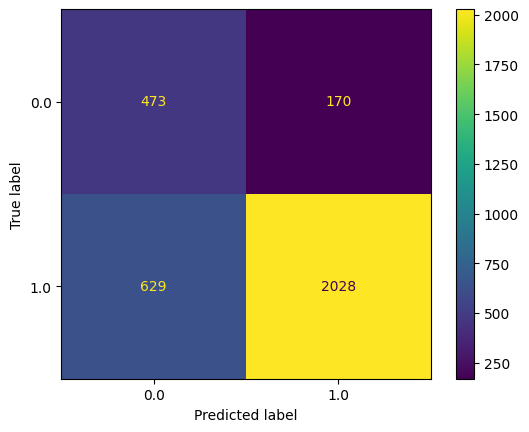

In [69]:
# choose one and stick with it
Dt_clf = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5)

# fit the model
Dt_clf.fit(X_res_scaled, y_res)  # ← you were missing this!

# predict
y_pred = Dt_clf.predict(X_test_scaled)

if APPLY_SCALER:
    X_test_scaled = scaler.transform(X_test)
else:
    X_test_scaled = X_test

# evaluate
print(classification_report(y_test, y_pred))

if SHOW_CONFMATRIX:
    ConfusionMatrixDisplay.from_estimator(Dt_clf, X_test_scaled, y_test)  # use scaled ✅